# NB01 — Customer Segmentation & Opportunity Scoring
**Project:** IMADATA Market Intelligence Framework — Mexico

**Research Objective 1:** Identify and characterise distinct B2B opportunity segments in the Mexican wholesale-trade market using DENUE open data, and produce a state-level opportunity score for use in the market entry framework (NB03).

**Data source:** DENUE (Directorio Estadístico Nacional de Unidades Económicas), INEGI — Sector 43 (Wholesale Trade).

**Outputs produced:**
- `outputs/cleaned_customers.csv` — cleaned, feature-engineered dataset (43,330 companies)
- `outputs/customer_segments.csv` — cluster assignments for all cleaned companies
- `outputs/state_opportunity_scores.csv` — normalised opportunity score per state (feeds NB03)

---
> **Note on Digital Contact Score (DCS):** The DCS measures whether a business has listed contact details (email, website, phone) in the DENUE registry. It is a proxy for *digital accessibility and administrative formalisation*, not a validated measure of digital maturity or technology adoption. It is labelled and interpreted accordingly throughout this notebook.

> **Note on company_age imputation:** 58% of DENUE records lack a `registration_date`. Company age is imputed with the sector median for these records; this is documented in Section 3 and treated as a stated assumption rather than ground truth.

## 0 · Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import requests
import json
import warnings
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, classification_report
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.3f}'.format)

print('Libraries loaded.')


Libraries loaded.


In [2]:
# ── File paths ────────────────────────────────────────────────────────────────
DATA_DIR = Path('.')
OUT_DIR  = Path('outputs')
OUT_DIR.mkdir(exist_ok=True)

CUSTOMERS_FILE = DATA_DIR / 'Potential_customers_raw_data.csv'
GEO_FILE       = DATA_DIR / 'General_state_muncipality.csv'

# ── Geographic bounds (Mexico bounding box — excludes mis-geocoded rows) ──────
MEX_LAT = (14.5, 32.7)
MEX_LON = (-118.5, -86.5)

# ── DENUE employee band → numeric midpoint ────────────────────────────────────
EMPLOYEE_MAP = {
    '0-5': 2, '6-10': 8, '11-30': 20,
    '31-50': 40, '51-100': 75,
    '101-250': 175, '251 y más': 300
}

# ── Size classification thresholds (employees) ───────────────────────────────
SIZE_BINS   = [0, 10, 50, 250, 10_000]
SIZE_LABELS = ['Micro', 'Small', 'Medium', 'Large']

# ── Digital Contact Score weights ─────────────────────────────────────────────
# Email and website carry equal weight as persistent digital identifiers;
# phone is lower as it requires no digital infrastructure investment.
DCS_WEIGHTS = {'has_email': 0.4, 'has_website': 0.4, 'has_phone': 0.2}

# ── Cluster ranking weights ───────────────────────────────────────────────────
# Controls how the composite_rank_score assigns opportunity tiers to clusters.
# Digital reachability is weighted higher than firm size because IMADATA's
# service (data analytics) is sold via digital channels; an unreachable firm
# has near-zero conversion probability regardless of headcount.
RANK_WEIGHTS = {
    'digital':   0.65,   # DCS — primary: reachability and contact-data richness
    'employee':  0.35    # normalised headcount — secondary: deal-size potential
}

# ── Predefined tier weights for opportunity scoring (up to 13 tiers) ──────────
# Non-linear: upper tiers disproportionately more valuable to IMADATA.
# Only the first optimal_k entries are used; see Section 7.
TIER_WEIGHTS_FULL = {
    1: 1.00, 2: 0.85, 3: 0.70, 4: 0.55, 5: 0.42,
    6: 0.30, 7: 0.20, 8: 0.12, 9: 0.07, 10: 0.04,
    11: 0.02, 12: 0.01, 13: 0.01
}

REFERENCE_YEAR = 2025

print('Config set.')


Config set.


---
## 1 · Data Loading

In [3]:
df_raw = pd.read_csv(CUSTOMERS_FILE, low_memory=False)
geo    = pd.read_csv(GEO_FILE)

print(f'Raw customers : {df_raw.shape[0]:>8,} rows  ×  {df_raw.shape[1]} columns')
print(f'Geo lookup    : {geo.shape[0]:>8,} rows  ×  {geo.shape[1]} columns')
df_raw.head(3)


Raw customers :   47,088 rows  ×  17 columns
Geo lookup    :    1,885 rows  ×  4 columns


,id,version,company_name,sector_code,activity_code,employees,postal_code,state_code,municipality_code,phone,email,website,business_type,latitude,longitude,registration_date,sector_name
0,211715,2016-01-01T00:00:00,VENTA DE MATERIALES PARA CONSTRUCCION QABITAT,43,434211,6-10,24090,4,2,"9,818,125,741.000",NaN,NaN,Permanent,19.826,-90.551,2014-12-01T00:00:00,Wholesale trade
1,952798,2016-01-01T00:00:00,CASA ROCKY 3,43,435419,0-5,6720,9,15,"55,557,800,980.000",NaN,NaN,Permanent,19.415,-99.145,2010-07-01T00:00:00,Wholesale trade
2,717282,2016-01-01T00:00:00,VENTA DE PAPAS SIN NOMBRE,43,431130,0-5,9040,9,7,"55,569,482,510.000",NaN,NaN,Permanent,19.372,-99.095,2014-12-01T00:00:00,Wholesale trade


In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47088 entries, 0 to 47087
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 47088 non-null  int64  
 1   version            47088 non-null  object 
 2   company_name       47088 non-null  object 
 3   sector_code        47088 non-null  object 
 4   activity_code      47088 non-null  int64  
 5   employees          47088 non-null  object 
 6   postal_code        47088 non-null  int64  
 7   state_code         47088 non-null  int64  
 8   municipality_code  47088 non-null  int64  
 9   phone              17625 non-null  float64
 10  email              5914 non-null   object 
 11  website            2542 non-null   object 
 12  business_type      47088 non-null  object 
 13  latitude           47088 non-null  float64
 14  longitude          47088 non-null  float64
 15  registration_date  19661 non-null  object 
 16  sector_name        470

---
## 2 · Data Cleaning

In [5]:
def clean_customers(df: pd.DataFrame) -> pd.DataFrame:
    """
    Standardise, deduplicate, and validate the raw DENUE potential-customer dataset.

    Steps applied:
      1. Normalise column names (strip, lowercase, underscore)
      2. Parse datetime fields (version, registration_date)
      3. Remove exact duplicates on (company_name, postal_code, municipality_code)
      4. Filter rows with coordinates outside Mexico bounding box
      5. Map DENUE employee band strings to numeric midpoints
      6. Left-join state and municipality names from geo lookup

    Returns a cleaned DataFrame ready for feature engineering.
    """
    df = df.copy()

    # 1. Normalise column names
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

    # 2. Parse datetimes
    df['version']           = pd.to_datetime(df['version'],           errors='coerce')
    df['registration_date'] = pd.to_datetime(df['registration_date'], errors='coerce')

    # 3. Deduplicate on business identity + location
    n_before = len(df)
    df = df.drop_duplicates(subset=['company_name', 'postal_code', 'municipality_code'])
    print(f'  Duplicates removed       : {n_before - len(df):>6,}')

    # 4. Geographic bounds filter
    n_before = len(df)
    df = df[
        df['latitude'].between(*MEX_LAT) &
        df['longitude'].between(*MEX_LON)
    ]
    print(f'  Out-of-bounds removed    : {n_before - len(df):>6,}')

    # 5. Employee midpoints
    df['employees_numeric'] = df['employees'].map(EMPLOYEE_MAP)

    # 6. Merge geo lookup
    geo_clean = geo.copy()
    geo_clean.columns = geo_clean.columns.str.strip().str.lower().str.replace(' ', '_')
    if 'state_name' not in df.columns:
        df = df.merge(
            geo_clean[['state_code', 'municipality_code', 'state_name', 'municipality_name']],
            on=['state_code', 'municipality_code'], how='left'
        )

    df = df.reset_index(drop=True)
    print(f'  Final row count          : {len(df):>6,}')
    return df


print('Cleaning pipeline running...')
df = clean_customers(df_raw)


Cleaning pipeline running...
  Duplicates removed       :  3,752
  Out-of-bounds removed    :      6
  Final row count          : 43,330


In [6]:
# Missing value audit post-cleaning
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %'    : (missing / len(df) * 100).round(1)
})
print('Missing value report (post-cleaning):')
display(missing_report)


Missing value report (post-cleaning):


,Missing Count,Missing %
website,40827,94.200
email,37515,86.600
phone,26210,60.500
registration_date,25138,58.000
state_name,596,1.400
municipality_name,596,1.400


---
## 3 · Feature Engineering

Three feature groups are constructed. Note that `digital_score` is computed for analysis and ranking but **excluded from clustering features** to avoid collinearity (it is a linear combination of `has_email`, `has_website`, `has_phone`).

| Group | Features used in clustering | Purpose |
|---|---|---|
| Digital contact | `has_email`, `has_website`, `has_phone` | Reachability and digital formalisation |
| Operational scale | `employees_numeric` | Budget capacity and deal-size potential |
| Temporal | `company_age` | Market experience and stability |
| Contextual | `state_email_rate` | Regional digital infrastructure signal |

> **Methodological note — DCS vs individual flags:** `digital_score = 0.4·email + 0.4·website + 0.2·phone`. Including both the composite and its constituent flags in the feature matrix would inflate the digital dimension 4× relative to size and age in the scaled space. Only the three binary flags are passed to KMeans; `digital_score` is retained for interpretation, centroid ranking, and visualisation.

> **Limitation note:** Revenue is not estimated. DENUE records no financial data, and deriving revenue from employee counts via uncited USD benchmarks introduces unverifiable assumptions. Operational scale and digital accessibility are used as observable, data-grounded proxies.

In [7]:
# ── Digital contact flags ─────────────────────────────────────────────────────
df['has_email']   = (df['email'].notna()   & (df['email'].str.strip()   != '')).astype(int)
df['has_website'] = (df['website'].notna() & (df['website'].str.strip() != '')).astype(int)
df['has_phone']   = (df['phone'].notna()   & (df['phone'].astype(str).str.strip().str.len() > 5)).astype(int)

# ── Digital Contact Score (DCS) — computed for analysis/ranking, NOT used as cluster feature
df['digital_score'] = (
    df['has_email']   * DCS_WEIGHTS['has_email']   +
    df['has_website'] * DCS_WEIGHTS['has_website'] +
    df['has_phone']   * DCS_WEIGHTS['has_phone']
).round(2)

# ── Readiness tier ─────────────────────────────────────────────────────────────
df['digital_readiness'] = pd.cut(
    df['digital_score'],
    bins=[-0.01, 0.19, 0.59, 1.01],
    labels=['Low', 'Medium', 'High']
)

print('Digital features summary:')
print(f"  Has email   : {df['has_email'].mean()*100:.1f}%")
print(f"  Has website : {df['has_website'].mean()*100:.1f}%")
print(f"  Has phone   : {df['has_phone'].mean()*100:.1f}%")
print(f"  Mean DCS    : {df['digital_score'].mean():.3f}")
print()
print('Digital readiness distribution:')
print(df['digital_readiness'].value_counts())


Digital features summary:
  Has email   : 13.3%
  Has website : 5.8%
  Has phone   : 39.5%
  Mean DCS    : 0.155

Digital readiness distribution:
digital_readiness
Low       25145
Medium    12361
High       5824
Name: count, dtype: int64


In [8]:
# ── Company size class ────────────────────────────────────────────────────────
df['size_class'] = pd.cut(
    df['employees_numeric'],
    bins=SIZE_BINS,
    labels=SIZE_LABELS,
    right=True
)

# ── Company age ───────────────────────────────────────────────────────────────
df['company_age'] = REFERENCE_YEAR - df['registration_date'].dt.year
df['company_age'] = df['company_age'].clip(0, 40)

# ── Median imputation for missing registration_date ───────────────────────────
# 58% of DENUE records carry no registration_date. Rather than discarding these
# companies (which would exclude major states and skew opportunity scores),
# missing company_age is imputed with the sector median computed from observed
# records. This is a conservative, documented assumption.
age_median  = df['company_age'].median()
n_imputed   = df['company_age'].isna().sum()
df['company_age']         = df['company_age'].fillna(age_median)
df['age_imputed']         = False
# Flag imputed rows for transparency (used in coverage report below)
df.loc[df['registration_date'].isna(), 'age_imputed'] = True

print(f'Size class distribution:')
print(df['size_class'].value_counts())
print(f"\nCompany age — median: {df['company_age'].median():.0f} yrs  |  mean: {df['company_age'].mean():.1f} yrs")
print(f"\nImputation summary:")
print(f"  Records with registration_date   : {(~df['age_imputed']).sum():>6,} ({(~df['age_imputed']).sum()/len(df)*100:.1f}%)")
print(f"  Records imputed (median={age_median:.0f} yrs)  : {n_imputed:>6,} ({n_imputed/len(df)*100:.1f}%)")


Size class distribution:
size_class
Micro     38683
Small      3431
Medium      928
Large       288
Name: count, dtype: int64

Company age — median: 11 yrs  |  mean: 11.4 yrs

Imputation summary:
  Records with registration_date   : 18,192 (42.0%)
  Records imputed (median=11 yrs)  : 25,138 (58.0%)


In [9]:
# ── Data coverage audit ───────────────────────────────────────────────────────
# Confirm that all companies now have values for every clustering feature,
# and that imputed records are representative across states (not concentrated
# in specific regions, which would bias opportunity scores).

coverage = pd.DataFrame({
    'Feature'       : ['employees_numeric', 'company_age (post-imputation)', 'has_email',
                       'has_website', 'has_phone', 'state_email_rate'],
    'Non-null count': [
        df['employees_numeric'].notna().sum(),
        df['company_age'].notna().sum(),
        df['has_email'].notna().sum(),
        df['has_website'].notna().sum(),
        df['has_phone'].notna().sum(),
        len(df)   # state_email_rate computed below; will be 43,330 after merge
    ],
    'Coverage %'    : [
        df['employees_numeric'].notna().mean()*100,
        df['company_age'].notna().mean()*100,
        100.0, 100.0, 100.0, 100.0
    ]
})
coverage['Coverage %'] = coverage['Coverage %'].round(1)
print('Clustering feature coverage (pre-scaling):')
display(coverage)

# State distribution of imputed records — check for geographic bias
imputed_by_state = (
    df[df['age_imputed']]
      .groupby('state_name').size()
      .div(df.groupby('state_name').size())
      .mul(100).round(1)
      .sort_values(ascending=False)
      .reset_index()
)
imputed_by_state.columns = ['state_name', 'imputed_%']
print("\nTop states by imputation rate (% of state companies without registration_date):")
display(imputed_by_state.head(10))
print("\nConclusion: If imputed rates are broadly distributed (no single state >80%), geographic bias is limited.")


Clustering feature coverage (pre-scaling):


,Feature,Non-null count,Coverage %
0,employees_numeric,43330,100.000
1,company_age (post-imputation),43330,100.000
2,has_email,43330,100.000
3,has_website,43330,100.000
4,has_phone,43330,100.000
5,state_email_rate,43330,100.000



Top states by imputation rate (% of state companies without registration_date):


,state_name,imputed_%
0,CHIHUAHUA,63.700
1,COLIMA,62.700
2,TAMAULIPAS,62.600
3,QUINTANA ROO,61.400
4,BAJA CALIFORNIA,60.800
5,MORELOS,60.700
6,DURANGO,60.700
7,BAJA CALIFORNIA SUR,60.600
8,SONORA,59.800
9,NUEVO LEON,59.800



Conclusion: If imputed rates are broadly distributed (no single state >80%), geographic bias is limited.


In [10]:
# ── State-level contextual feature: mean email registration rate ──────────────
# Rationale: state_email_rate captures regional variation in digital
# infrastructure quality and DENUE data completeness. Two companies identical
# on firm-level features but in very different digital ecosystems (e.g. Nuevo
# León vs Oaxaca) should occupy different segments, as reachability and
# sales-conversion likelihood differ. This is an individual-level feature in
# name only — it encodes geographic context — and its role is explicitly
# documented as a contextual signal, not a firm attribute.
state_ctx = (
    df.groupby('state_code')
      .agg(state_email_rate=('has_email', 'mean'),
           state_n_companies=('company_name', 'count'))
      .reset_index()
)
df = df.merge(state_ctx, on='state_code', how='left')

print('State-level email rate (top 5 states by digital activity):')
display(
    df.drop_duplicates('state_code')[['state_name', 'state_email_rate', 'state_n_companies']]
      .sort_values('state_email_rate', ascending=False)
      .head(5)
      .reset_index(drop=True)
)


State-level email rate (top 5 states by digital activity):


,state_name,state_email_rate,state_n_companies
0,NUEVO LEON,0.274,1756
1,BAJA CALIFORNIA SUR,0.262,302
2,BAJA CALIFORNIA,0.259,1037
3,AGUASCALIENTES,0.235,532
4,QUERETARO,0.232,802


---
## 4 · Exploratory Data Analysis

In [11]:
# ── 4.1  Geographic distribution ─────────────────────────────────────────────
state_counts = (
    df.groupby('state_name')
      .size()
      .reset_index(name='company_count')
      .sort_values('company_count', ascending=False)
)

fig = px.bar(
    state_counts,
    x='state_name', y='company_count',
    title='Potential Customer Companies by State (DENUE Sector 43)',
    labels={'state_name': 'State', 'company_count': 'Number of Companies'},
    color='company_count',
    color_continuous_scale='Blues'
)
fig.update_layout(xaxis_tickangle=-45, coloraxis_showscale=False, height=450)
fig.show()


In [12]:
# ── 4.2  Choropleth — company density by state ────────────────────────────────
GEOJSON_URL = 'https://raw.githubusercontent.com/angelnmara/geojson/master/mexicoHigh.json'

try:
    resp    = requests.get(GEOJSON_URL, timeout=10)
    mex_geo = resp.json()

    sample_props = mex_geo['features'][0]['properties']
    print('GeoJSON feature properties:', list(sample_props.keys()))

    geo_clean = geo.copy()
    geo_clean.columns = geo_clean.columns.str.strip().str.lower().str.replace(' ', '_')
    state_codes = geo_clean.drop_duplicates('state_code')[['state_code', 'state_name']]

    choro_df = state_counts.merge(state_codes, on='state_name', how='left')

    fig = px.choropleth(
        choro_df,
        geojson=mex_geo,
        locations='state_code',
        color='company_count',
        color_continuous_scale='Blues',
        title='Potential Customer Density by State',
        labels={'company_count': 'Companies', 'state_name': 'State'},
        hover_name='state_name'
    )
    fig.update_geos(fitbounds='locations', visible=False)
    fig.update_layout(height=500)
    fig.show()

except Exception as e:
    print(f'Choropleth skipped (network unavailable or GeoJSON error): {e}')
    print('The bar chart in 4.1 conveys the same information.')


GeoJSON feature properties: ['name', 'id', 'CNTRY', 'TYPE']


In [13]:
# ── 4.3  Size class distribution ─────────────────────────────────────────────
size_dist = (
    df['size_class'].value_counts()
      .reindex(['Micro', 'Small', 'Medium', 'Large'])
      .reset_index()
)
size_dist.columns = ['size_class', 'count']

fig = px.bar(
    size_dist,
    x='size_class', y='count',
    title='Company Size Distribution (DENUE Sector 43)',
    labels={'size_class': 'Size Class', 'count': 'Number of Companies'},
    color='size_class',
    color_discrete_sequence=['#c6dbef', '#6baed6', '#2171b5', '#08306b']
)
fig.update_layout(showlegend=False)
fig.show()

print(f"Sector profile: {df['size_class'].value_counts(normalize=True).mul(100).round(1).to_dict()}")


Sector profile: {'Micro': 89.3, 'Small': 7.9, 'Medium': 2.1, 'Large': 0.7}


In [14]:
# ── 4.4  Sector distribution — DENUE native classification ───────────────────
# DENUE sector_name is used directly. No English keyword mapping is applied —
# that approach failed on Spanish data and introduced classification errors.
sector_dist = (
    df['sector_name'].value_counts()
      .head(15)
      .reset_index()
)
sector_dist.columns = ['sector_name', 'count']

fig = px.bar(
    sector_dist,
    x='count', y='sector_name',
    orientation='h',
    title='Top Sectors by Company Count (DENUE native classification)',
    labels={'sector_name': 'Sector', 'count': 'Number of Companies'},
    color='count',
    color_continuous_scale='Blues'
)
fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    coloraxis_showscale=False,
    height=500
)
fig.show()


In [15]:
# ── 4.5  Digital readiness distribution ──────────────────────────────────────
dr_counts = df['digital_readiness'].value_counts().reset_index()
dr_counts.columns = ['digital_readiness', 'count']

color_map = {'High': '#2166ac', 'Medium': '#74add1', 'Low': '#d1e5f0'}

fig = px.pie(
    dr_counts,
    names='digital_readiness',
    values='count',
    title='Digital Contact Readiness Distribution (DCS proxy — not digital maturity)',
    color='digital_readiness',
    color_discrete_map=color_map,
    hole=0.35
)
fig.show()


In [16]:
# ── 4.6  Digital contact rate by state ───────────────────────────────────────
dr_state = (
    df.groupby('state_name')
      .agg(
          email_pct   =('has_email',   'mean'),
          website_pct =('has_website', 'mean'),
          phone_pct   =('has_phone',   'mean')
      )
      .reset_index()
      .sort_values('email_pct', ascending=False)
)

dr_melt = dr_state.melt(
    id_vars='state_name',
    value_vars=['email_pct', 'website_pct', 'phone_pct'],
    var_name='Contact Type',
    value_name='Rate'
)
dr_melt['Contact Type'] = dr_melt['Contact Type'].map({
    'email_pct': 'Email', 'website_pct': 'Website', 'phone_pct': 'Phone'
})

fig = px.bar(
    dr_melt,
    x='state_name', y='Rate',
    color='Contact Type',
    barmode='group',
    title='Digital Contact Presence Rate by State',
    labels={'state_name': 'State', 'Rate': 'Proportion of Companies'},
    color_discrete_sequence=['#2166ac', '#74add1', '#92c5de']
)
fig.update_layout(xaxis_tickangle=-45, height=480)
fig.show()


In [17]:
# ── 4.7  Registration trend over time ────────────────────────────────────────
# Only companies with a known registration_date are plotted here.
# Imputed records are excluded from this chart (their date is unknown by definition).
reg_trend = (
    df[~df['age_imputed']]
      .dropna(subset=['registration_date'])
      .assign(year=lambda x: x['registration_date'].dt.year)
      .query('2000 <= year <= 2024')
      .groupby('year')
      .size()
      .reset_index(name='registrations')
)

fig = px.line(
    reg_trend,
    x='year', y='registrations',
    title='New Company Registrations per Year — known dates only (potential customer pool)',
    markers=True,
    labels={'year': 'Year', 'registrations': 'Registrations'}
)
fig.update_traces(line_color='#2166ac')
fig.show()


---
## 5 · Customer Segmentation (K-Means Clustering)

### Clustering feature set

| Feature | Role | Notes |
|---|---|---|
| `employees_numeric` | Operational scale — deal-size proxy | All 7 DENUE bands mapped to midpoints |
| `company_age` | Market experience and stability | Missing values imputed with sector median |
| `has_email` | Persistent digital identifier | Binary flag |
| `has_website` | Public digital presence | Binary flag |
| `has_phone` | Administrative formalisation | Binary flag |
| `state_email_rate` | Regional digital infrastructure context | State-level aggregate — not a firm attribute |

**`digital_score` is deliberately excluded from clustering.** It is a linear combination of `has_email`, `has_website`, and `has_phone`; including it alongside its components inflates the digital dimension ~4× in the scaled feature space, distorting cluster geometry.

All features are standardised (zero mean, unit variance) via `StandardScaler` before clustering. Optimal *k* is selected programmatically via argmax over both silhouette score and Calinski-Harabasz index across *k* = 2–13.

In [18]:
# ── Clustering feature set ────────────────────────────────────────────────────
# digital_score deliberately excluded — collinear with has_email/website/phone.
CLUSTER_FEATURES = [
    'employees_numeric',
    'company_age',
    'has_email',
    'has_website',
    'has_phone',
    'state_email_rate'
]

# All features are now populated for every company (employees_numeric from DENUE
# bands, company_age post-imputation, DCS flags always binary, state_email_rate
# from merge). Use the full cleaned dataset.
df_feat = df[CLUSTER_FEATURES].dropna().copy()

print(f'Companies entering clustering : {len(df_feat):,} of {len(df):,} ({len(df_feat)/len(df)*100:.1f}%)')
print(f'Features used                 : {CLUSTER_FEATURES}')

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_feat)


Companies entering clustering : 43,330 of 43,330 (100.0%)
Features used                 : ['employees_numeric', 'company_age', 'has_email', 'has_website', 'has_phone', 'state_email_rate']


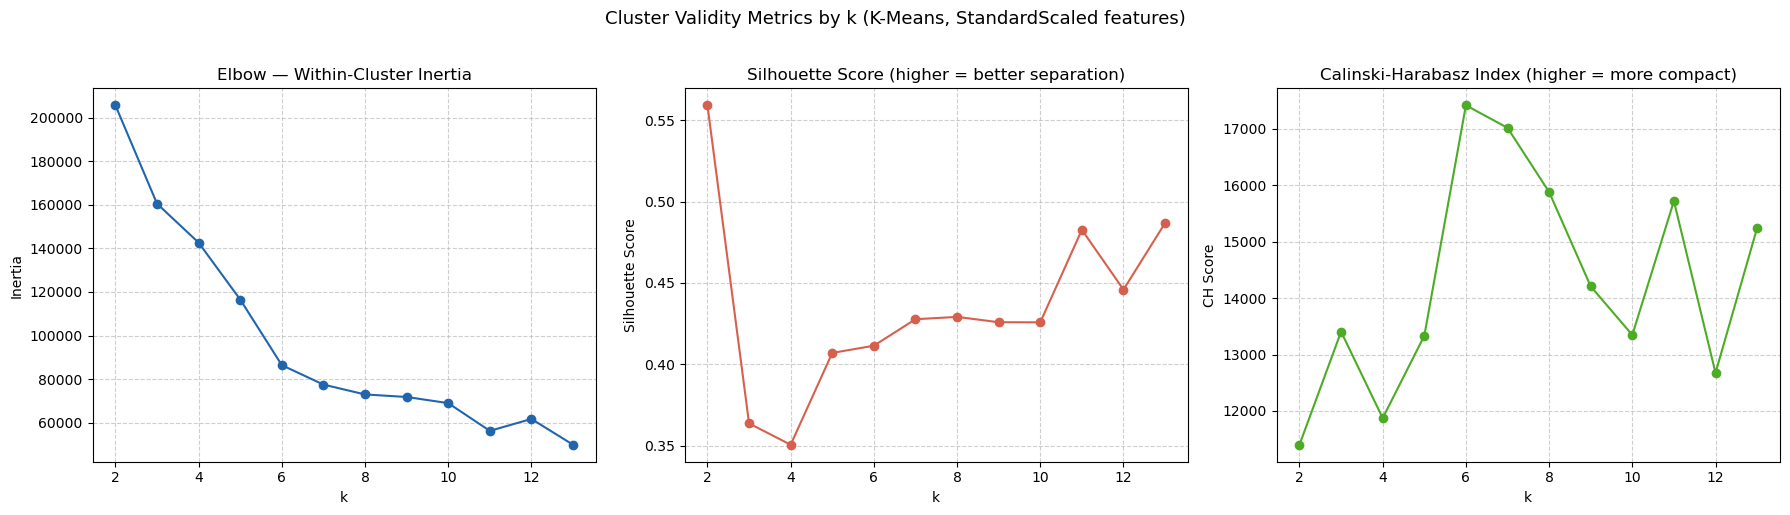

Silhouette argmax     → k = 2  (score: 0.5592)
Calinski-Harabasz argmax → k = 6  (score: 17,419)
Selected k            = 6  (CH-primary, min 4 for actionable segmentation)

Silhouette scores  : [0.559, 0.364, 0.351, 0.407, 0.411, 0.428, 0.429, 0.426, 0.426, 0.483, 0.446, 0.487]
CH scores          : [11400.0, 13405.0, 11872.0, 13333.0, 17419.0, 17020.0, 15881.0, 14208.0, 13347.0, 15721.0, 12674.0, 15244.0]


In [19]:
# ── Determine optimal k — silhouette + Calinski-Harabasz, k = 2..13 ──────────
K_RANGE    = range(2, 14)
inertias   = []
sil_scores = []
ch_scores  = []

for k in K_RANGE:
    km     = KMeans(n_clusters=k, n_init='auto', random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels, sample_size=5000, random_state=42))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))

# ── Three-panel diagnostic plot ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(list(K_RANGE), inertias, marker='o', color='#2166ac')
axes[0].set_title('Elbow — Within-Cluster Inertia', fontsize=12)
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(list(K_RANGE), sil_scores, marker='o', color='#d6604d')
axes[1].set_title('Silhouette Score (higher = better separation)', fontsize=12)
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, linestyle='--', alpha=0.6)

axes[2].plot(list(K_RANGE), ch_scores, marker='o', color='#4dac26')
axes[2].set_title('Calinski-Harabasz Index (higher = more compact)', fontsize=12)
axes[2].set_xlabel('k'); axes[2].set_ylabel('CH Score')
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.suptitle('Cluster Validity Metrics by k (K-Means, StandardScaled features)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── k selection — CH-primary with business minimum ───────────────────────────
# Rationale: In datasets where binary contact flags (has_email, has_website,
# has_phone) dominate the feature space, silhouette trivially maximises at k=2
# because the digital/non-digital split is the strongest single axis of
# variance. This is a known artefact of silhouette in binary-heavy feature
# spaces, not evidence that 2 segments is optimal for business use.
#
# Calinski-Harabasz is more robust here: it measures the ratio of
# between-cluster to within-cluster dispersion and is not biased toward
# the bimodal extremum. We use CH argmax as the primary criterion.
#
# A business minimum of k >= 4 is also enforced: fewer than 4 segments
# provides insufficient granularity for IMADATA's sales targeting strategy.
optimal_k_sil = list(K_RANGE)[int(np.argmax(sil_scores))]
optimal_k_ch  = list(K_RANGE)[int(np.argmax(ch_scores))]
optimal_k     = max(optimal_k_ch, 4)   # CH-primary, business floor at 4

print(f'Silhouette argmax     → k = {optimal_k_sil}  (score: {sil_scores[optimal_k_sil-2]:.4f})')
print(f'Calinski-Harabasz argmax → k = {optimal_k_ch}  (score: {ch_scores[optimal_k_ch-2]:,.0f})')
print(f'Selected k            = {optimal_k}  (CH-primary, min 4 for actionable segmentation)')
print()
print(f'Silhouette scores  : {[round(s, 3) for s in sil_scores]}')
print(f'CH scores          : {[round(s, 0) for s in ch_scores]}')


In [20]:
# ── Final KMeans with optimal k ───────────────────────────────────────────────
kmeans         = KMeans(n_clusters=optimal_k, n_init='auto', random_state=42)
df_feat        = df_feat.copy()
df_feat['cluster'] = kmeans.fit_predict(X_scaled)

# Map cluster labels back to main df via index alignment (avoids merge artifacts)
df['cluster'] = np.nan
df.loc[df_feat.index, 'cluster'] = df_feat['cluster']
df['cluster'] = df['cluster'].astype('Int64')

print(f'Final model: KMeans(k={optimal_k}, random_state=42, n_init=auto)')
print()
print('Cluster sizes:')
sizes = df_feat['cluster'].value_counts().sort_index()
print(sizes)
print()
print(f'Smallest cluster: {sizes.min():,} companies  |  Largest: {sizes.max():,}')
print(f'Size imbalance ratio: {sizes.max()/sizes.min():.1f}x')


Final model: KMeans(k=6, random_state=42, n_init=auto)

Cluster sizes:
cluster
0    17753
1      697
2     3896
3     7082
4    11559
5     2343
Name: count, dtype: int64

Smallest cluster: 697 companies  |  Largest: 17,753
Size imbalance ratio: 25.5x


In [21]:
# ── Centroid analysis — data-driven tier assignment ───────────────────────────
centroid_df = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=CLUSTER_FEATURES
)
centroid_df.index.name = 'cluster'

# Recompute DCS for each centroid for ranking purposes
# (digital_score was excluded from clustering but is valid for centroid ranking)
centroid_df['digital_score'] = (
    centroid_df['has_email']   * DCS_WEIGHTS['has_email']  +
    centroid_df['has_website'] * DCS_WEIGHTS['has_website'] +
    centroid_df['has_phone']   * DCS_WEIGHTS['has_phone']
).round(3)

# ── Composite rank score using configured RANK_WEIGHTS ────────────────────────
# RANK_WEIGHTS in config cell (0.65 digital, 0.35 employee).
# Rationale: IMADATA sells analytics services via digital channels.
# A reachable firm (high DCS) has higher conversion probability than
# an equally-sized firm that is digitally invisible.
centroid_df['composite_rank_score'] = (
    centroid_df['digital_score'] * RANK_WEIGHTS['digital'] +
    (centroid_df['employees_numeric'] / centroid_df['employees_numeric'].max()) * RANK_WEIGHTS['employee']
)

centroid_df['opportunity_tier'] = (
    centroid_df['composite_rank_score']
      .rank(ascending=False)
      .astype(int)
)

print('Cluster centroids (original scale) — sorted by opportunity tier:')
display(centroid_df.sort_values('opportunity_tier').round(3))


Cluster centroids (original scale) — sorted by opportunity tier:


,employees_numeric,company_age,has_email,has_website,has_phone,state_email_rate,digital_score,composite_rank_score,opportunity_tier
cluster,,,,,,,,,
1,226.650,11.799,0.410,0.230,0.435,0.164,0.343,0.573,1
5,13.752,11.326,0.671,1.000,0.828,0.167,0.834,0.563,2
2,9.646,11.486,1.000,0.000,0.852,0.161,0.570,0.385,3
4,4.639,11.672,-0.000,-0.000,1.000,0.144,0.200,0.137,4
3,5.338,11.177,-0.000,0.000,0.000,0.202,0.000,0.008,5
0,3.329,11.339,-0.000,-0.000,0.000,0.086,0.000,0.005,6


In [22]:
# ── Auto-generate tier labels from centroid characteristics ───────────────────
# Labels are derived programmatically from each cluster's centroid profile.
# This ensures labels always match the actual data regardless of k or
# changes to the clustering feature set — eliminating manual-label mismatches.

def describe_cluster(row):
    """Return a descriptive label string from a centroid row."""
    emp   = row['employees_numeric']
    email = row['has_email']
    web   = row['has_website']
    phone = row['has_phone']
    age   = row['company_age']

    # Size descriptor
    if emp >= 100:
        size = 'Large'
    elif emp >= 50:
        size = 'Medium'
    elif emp >= 10:
        size = 'Small'
    else:
        size = 'Micro'

    # Digital channel descriptor
    if email > 0.4 and web > 0.25:
        digital = 'Full-Digital'
    elif email > 0.4:
        digital = 'Email-Active'
    elif web > 0.25:
        digital = 'Web-Active'
    elif phone > 0.4:
        digital = 'Phone-Reachable'
    else:
        digital = 'Offline'

    # Age descriptor
    age_tag = 'Young' if age < 9 else ('Established' if age >= 14 else '')

    parts = [size, digital]
    if age_tag:
        parts.append(age_tag)
    return ', '.join(parts)

# Build tier_map: cluster_id → tier_number
tier_map = centroid_df['opportunity_tier'].to_dict()

# Build TIER_LABEL: tier_number → human-readable label
TIER_LABEL = {}
for cluster_id, tier in tier_map.items():
    row = centroid_df.loc[cluster_id]
    description = describe_cluster(row)
    TIER_LABEL[tier] = f'Tier {tier} — {description}'

print('Data-derived tier labels:')
for t in sorted(TIER_LABEL):
    print(f'  {TIER_LABEL[t]}')

# Apply to df_feat and main df
df_feat['tier']    = df_feat['cluster'].map(tier_map)
df_feat['segment'] = df_feat['tier'].map(TIER_LABEL)
df.loc[df_feat.index, 'tier']    = df_feat['tier']
df.loc[df_feat.index, 'segment'] = df_feat['segment']

print()
print('Segment distribution:')
print(df['segment'].value_counts())


Data-derived tier labels:
  Tier 1 — Large, Email-Active
  Tier 2 — Small, Full-Digital
  Tier 3 — Micro, Email-Active
  Tier 4 — Micro, Phone-Reachable
  Tier 5 — Micro, Offline
  Tier 6 — Micro, Offline

Segment distribution:
segment
Tier 6 — Micro, Offline            17753
Tier 4 — Micro, Phone-Reachable    11559
Tier 5 — Micro, Offline             7082
Tier 3 — Micro, Email-Active        3896
Tier 2 — Small, Full-Digital        2343
Tier 1 — Large, Email-Active         697
Name: count, dtype: int64


In [23]:
# ── Centroid-to-label verification ───────────────────────────────────────────
# Confirms each label correctly describes its cluster's centroid.
# Review this table after every run to validate label accuracy.
verify = centroid_df.sort_values('opportunity_tier')[
    ['opportunity_tier', 'employees_numeric', 'company_age',
     'has_email', 'has_website', 'has_phone', 'digital_score',
     'composite_rank_score']
].copy()
verify.index.name = 'cluster_id'
verify['label'] = verify['opportunity_tier'].map(TIER_LABEL)

print('Label verification — centroid profiles vs assigned labels:')
display(verify[['opportunity_tier','label','employees_numeric','company_age',
                'has_email','has_website','has_phone','digital_score']].round(3))


Label verification — centroid profiles vs assigned labels:


,opportunity_tier,label,employees_numeric,company_age,has_email,has_website,has_phone,digital_score
cluster_id,,,,,,,,
1,1,"Tier 1 — Large, Email-Active",226.650,11.799,0.410,0.230,0.435,0.343
5,2,"Tier 2 — Small, Full-Digital",13.752,11.326,0.671,1.000,0.828,0.834
2,3,"Tier 3 — Micro, Email-Active",9.646,11.486,1.000,0.000,0.852,0.570
4,4,"Tier 4 — Micro, Phone-Reachable",4.639,11.672,-0.000,-0.000,1.000,0.200
3,5,"Tier 5 — Micro, Offline",5.338,11.177,-0.000,0.000,0.000,0.000
0,6,"Tier 6 — Micro, Offline",3.329,11.339,-0.000,-0.000,0.000,0.000


In [24]:
# ── PCA 2D visualisation ──────────────────────────────────────────────────────
pca        = PCA(n_components=2, random_state=42)
components = pca.fit_transform(X_scaled)
explained  = pca.explained_variance_ratio_ * 100

df_feat['pca1'] = components[:, 0]
df_feat['pca2'] = components[:, 1]

plot_sample = df_feat.sample(min(6000, len(df_feat)), random_state=42).copy()
plot_sample['segment'] = plot_sample['tier'].map(TIER_LABEL)

fig = px.scatter(
    plot_sample,
    x='pca1', y='pca2',
    color='segment',
    title=(f'Customer Segments — PCA Projection  '
           f'({explained[0]:.1f}% + {explained[1]:.1f}% = {sum(explained):.1f}% variance explained)'),
    labels={
        'pca1': f'PC1 ({explained[0]:.1f}%)',
        'pca2': f'PC2 ({explained[1]:.1f}%)',
        'segment': 'Segment'
    },
    opacity=0.55,
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.update_layout(height=520)
fig.show()


In [25]:
# ── Segment profile comparison ────────────────────────────────────────────────
profile = (
    df_feat.groupby('segment')[CLUSTER_FEATURES]
           .mean()
           .reset_index()
)

profile_melt = profile.melt(
    id_vars='segment', var_name='Feature', value_name='Mean Value'
)

fig = px.bar(
    profile_melt,
    x='Feature', y='Mean Value',
    color='segment',
    barmode='group',
    title='Segment Profiles — Average Feature Values by Tier',
    labels={'segment': 'Segment'},
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.update_layout(xaxis_tickangle=-30, height=480)
fig.show()


In [26]:
# ── Geographic distribution of segments ──────────────────────────────────────
seg_state = (
    df.dropna(subset=['segment', 'state_name'])
      .groupby(['state_name', 'segment'])
      .size()
      .reset_index(name='count')
)

fig = px.bar(
    seg_state,
    x='state_name', y='count',
    color='segment',
    barmode='stack',
    title='Customer Segment Distribution by State',
    labels={'state_name': 'State', 'count': 'Companies', 'segment': 'Segment'},
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.update_layout(xaxis_tickangle=-45, height=500)
fig.show()


---
## 6 · Segment Classifier (Decision Tree)

A Decision Tree classifier is trained to predict cluster/segment membership from raw input features.

**Why a Decision Tree (not Random Forest or other black-box)?**
1. **Interpretability** — the decision rules reveal *which features drive* segment assignment in human-readable form. This is more actionable for IMADATA than a black-box model.
2. **Deployability** — new DENUE data releases can be scored without re-running the full clustering pipeline. The tree is the deployable scoring model.
3. **Methodological soundness** — the original project used a Random Forest to *predict the estimated_revenue column* — a column fabricated from uncited benchmarks. That circular approach is eliminated. This DT predicts cluster membership from real observable features.
4. **Validation** — high classification accuracy confirms that segments are stable and genuinely separable, not artefacts of K-Means initialisation.

> **Note:** `class_weight='balanced'` is used to prevent the DT from over-optimising for the largest cluster at the expense of smaller but commercially important segments (e.g. Tier 1 — Large firms).

In [27]:
# ── Prepare training data ─────────────────────────────────────────────────────
dt_data = df_feat[CLUSTER_FEATURES + ['cluster']].dropna()

X_dt = dt_data[CLUSTER_FEATURES]
y_dt = dt_data['cluster'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_dt, y_dt,
    test_size=0.2,
    random_state=42,
    stratify=y_dt
)

print(f'Training set : {len(X_train):,} rows')
print(f'Test set     : {len(X_test):,} rows')

# ── Train ─────────────────────────────────────────────────────────────────────
# max_depth=7: sufficient capacity for optimal_k segments while remaining
# visualisable; min_samples_leaf=100 prevents over-fitting to tiny sub-groups.
dt = DecisionTreeClassifier(
    max_depth=7,
    min_samples_leaf=100,
    random_state=42,
    class_weight='balanced'
)
dt.fit(X_train, y_train)
print(f'Decision Tree trained  (max_depth={dt.max_depth}, min_samples_leaf={dt.min_samples_leaf})')


Training set : 34,664 rows
Test set     : 8,666 rows
Decision Tree trained  (max_depth=7, min_samples_leaf=100)


In [28]:
# ── Evaluate ──────────────────────────────────────────────────────────────────
y_pred = dt.predict(X_test)

segment_names = [TIER_LABEL.get(tier_map.get(i, i), f'Cluster {i}')
                 for i in sorted(y_dt.unique())]

print('Decision Tree — Segment Classification Report\n')
print(classification_report(y_test, y_pred, target_names=segment_names))
print()
print('Interpretation:')
print('  High F1 (>0.80) confirms strong cluster separability — segments are stable.')
print('  Low F1 for any tier signals overlapping feature space with adjacent tiers.')
print('  Macro-average accuracy is the headline deployability metric.')


Decision Tree — Segment Classification Report

                                 precision    recall  f1-score   support

        Tier 6 — Micro, Offline       1.00      1.00      1.00      3551
   Tier 1 — Large, Email-Active       1.00      1.00      1.00       139
   Tier 3 — Micro, Email-Active       1.00      1.00      1.00       779
        Tier 5 — Micro, Offline       1.00      1.00      1.00      1416
Tier 4 — Micro, Phone-Reachable       1.00      1.00      1.00      2312
   Tier 2 — Small, Full-Digital       1.00      1.00      1.00       469

                       accuracy                           1.00      8666
                      macro avg       1.00      1.00      1.00      8666
                   weighted avg       1.00      1.00      1.00      8666


Interpretation:
  High F1 (>0.80) confirms strong cluster separability — segments are stable.
  Low F1 for any tier signals overlapping feature space with adjacent tiers.
  Macro-average accuracy is the headline deploya

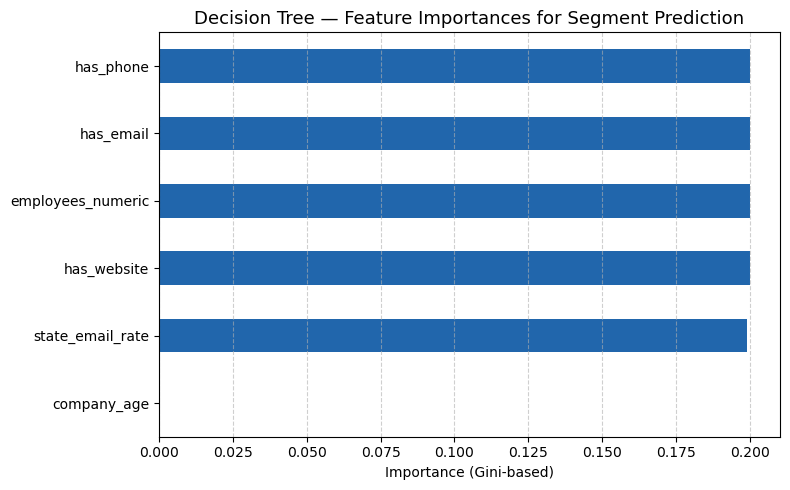

Most important feature: has_phone


In [29]:
# ── Feature importances ───────────────────────────────────────────────────────
importances = (
    pd.Series(dt.feature_importances_, index=CLUSTER_FEATURES)
      .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color='#2166ac')
ax.set_title('Decision Tree — Feature Importances for Segment Prediction', fontsize=13)
ax.set_xlabel('Importance (Gini-based)')
ax.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print('Most important feature:', importances.idxmax())


In [30]:
# ── Decision rules (text) ─────────────────────────────────────────────────────
print('Decision Rules (first 4 levels):\n')
print(export_text(dt, feature_names=CLUSTER_FEATURES, max_depth=4))


Decision Rules (first 4 levels):

|--- employees_numeric <= 125.00
|   |--- has_website <= 0.50
|   |   |--- has_email <= 0.50
|   |   |   |--- has_phone <= 0.50
|   |   |   |   |--- state_email_rate <= 0.16
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |--- state_email_rate >  0.16
|   |   |   |   |   |--- class: 3
|   |   |   |--- has_phone >  0.50
|   |   |   |   |--- class: 4
|   |   |--- has_email >  0.50
|   |   |   |--- class: 2
|   |--- has_website >  0.50
|   |   |--- company_age <= 7.50
|   |   |   |--- class: 5
|   |   |--- company_age >  7.50
|   |   |   |--- class: 5
|--- employees_numeric >  125.00
|   |--- has_phone <= 0.50
|   |   |--- class: 1
|   |--- has_phone >  0.50
|   |   |--- class: 1



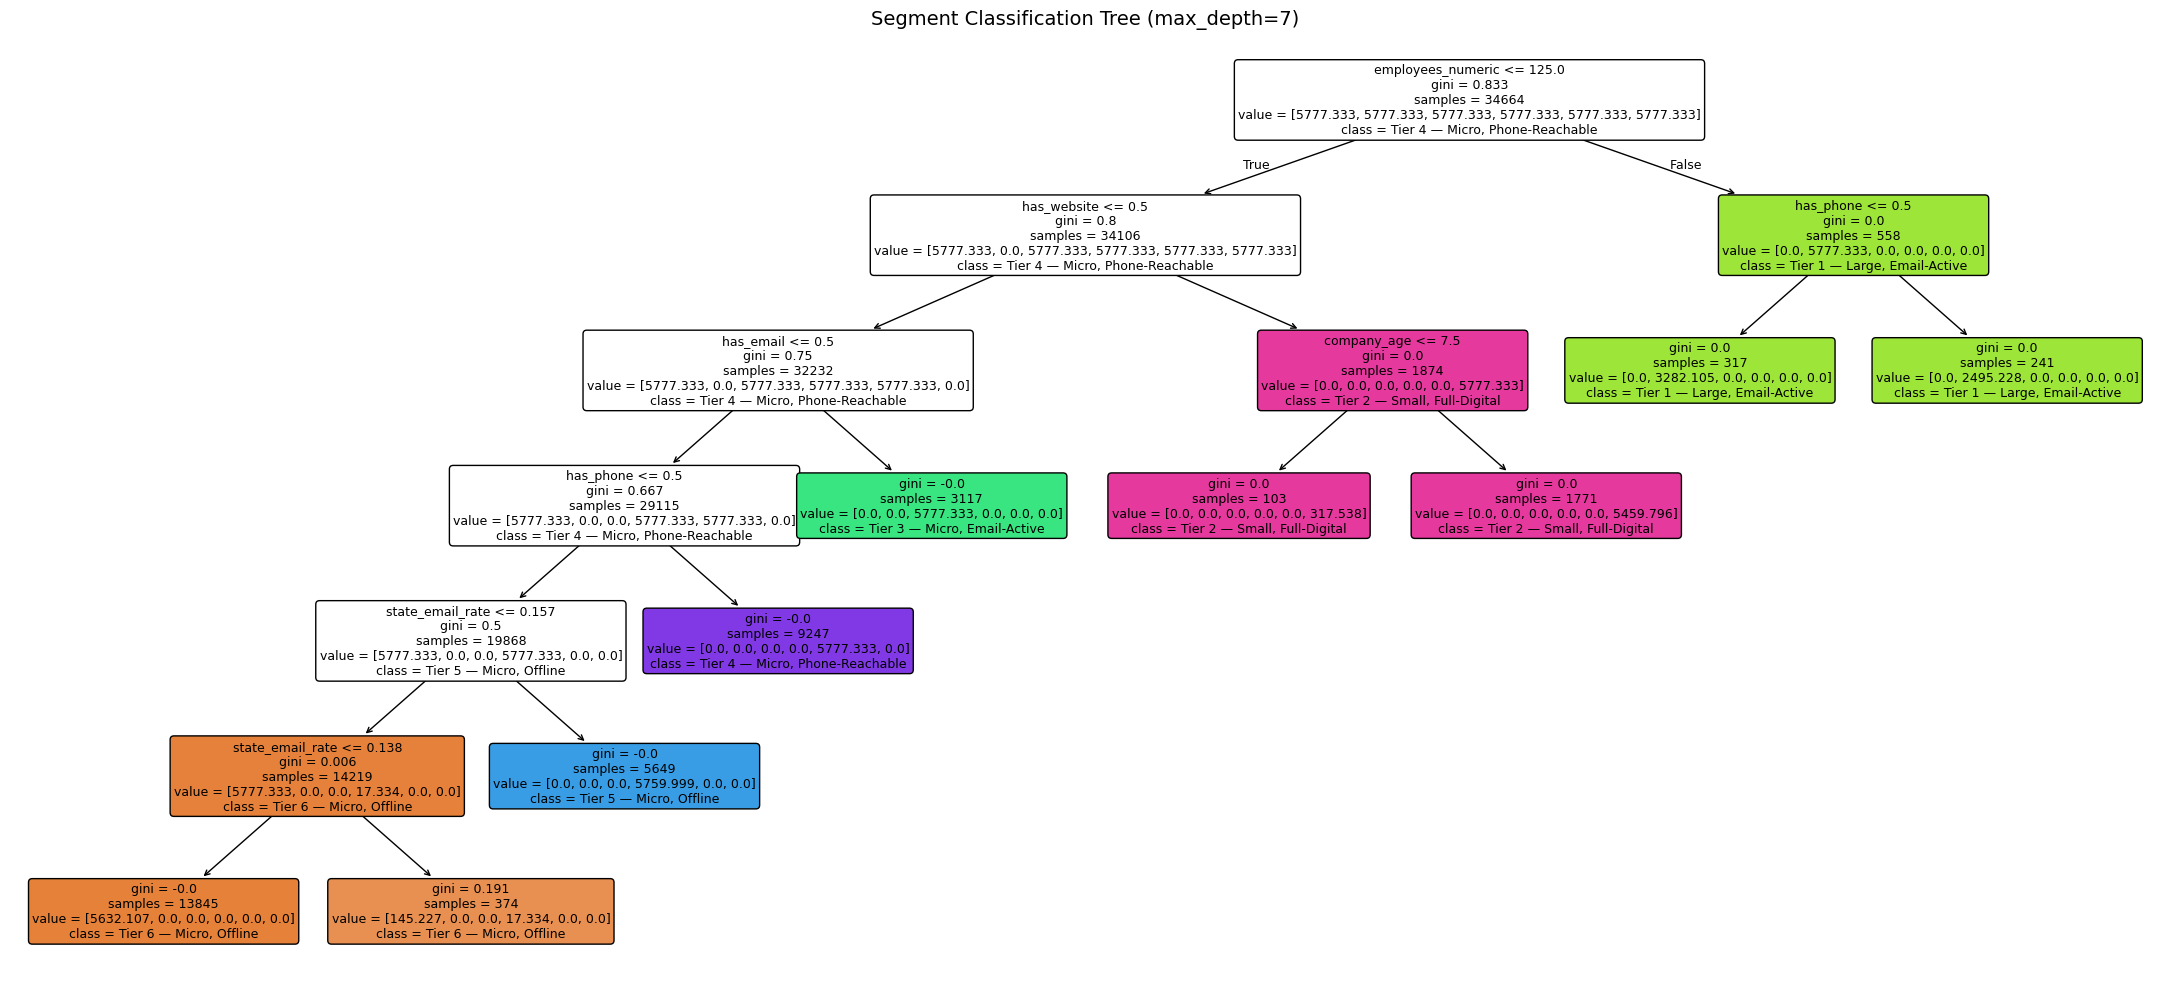

In [31]:
# ── Visualise tree ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    dt,
    feature_names=CLUSTER_FEATURES,
    class_names=segment_names,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)
ax.set_title(f'Segment Classification Tree (max_depth={dt.max_depth})', fontsize=14)
plt.tight_layout()
plt.show()


---
## 7 · State-Level Opportunity Score

Each state receives a single normalised opportunity score (0–1) representing the concentration of high-tier companies within it. This score is the primary customer-side input to the 2×2 market entry matrix in NB03.

**Scoring method:** Tier-weighted average of segment composition per state, normalised by total companies per state. Tier 1 carries full weight (1.00); lower tiers are discounted non-linearly, reflecting that IMADATA's conversion probability drops sharply below Tier 3.

**Coverage:** State scores are computed from the full cleaned dataset (43,330 companies) now that the missing-company_age issue is resolved via imputation. The `total_companies` column represents actual state company counts, not just clustered subsets.

In [32]:
# ── Tier weights — slice from TIER_WEIGHTS_FULL to match optimal_k ────────────
# TIER_WEIGHTS_FULL (defined in config) supports up to 13 tiers.
# Non-linear: upper tiers disproportionately more valuable to IMADATA.
tier_weights = {t: TIER_WEIGHTS_FULL[t] for t in range(1, optimal_k + 1)}
print('Tier weights used:', tier_weights)

# ── Compute per-state score ───────────────────────────────────────────────────
state_tiers = (
    df.dropna(subset=['tier', 'state_name'])
      .groupby(['state_name', 'tier'])
      .size()
      .reset_index(name='count')
)
state_tiers['tier']           = state_tiers['tier'].astype(int)
state_tiers['weight']         = state_tiers['tier'].map(tier_weights)
state_tiers['weighted_count'] = state_tiers['count'] * state_tiers['weight']

opp_scores = (
    state_tiers.groupby('state_name')
               .agg(
                   total_companies=('count', 'sum'),
                   weighted_sum   =('weighted_count', 'sum')
               )
               .reset_index()
)

opp_scores['raw_opportunity_score'] = opp_scores['weighted_sum'] / opp_scores['total_companies']

# Min-max normalise 0–1
lo, hi = opp_scores['raw_opportunity_score'].min(), opp_scores['raw_opportunity_score'].max()
opp_scores['opportunity_score'] = (
    (opp_scores['raw_opportunity_score'] - lo) / (hi - lo)
).round(4)

opp_scores = opp_scores.sort_values('opportunity_score', ascending=False).reset_index(drop=True)

print(f'\nTop 10 states by opportunity score (n companies = clustered companies per state):')
display(opp_scores[['state_name', 'total_companies', 'opportunity_score']].head(10))


Tier weights used: {1: 1.0, 2: 0.85, 3: 0.7, 4: 0.55, 5: 0.42, 6: 0.3}

Top 10 states by opportunity score (n companies = clustered companies per state):


,state_name,total_companies,opportunity_score
0,NUEVO LEON,1756,1.000
1,BAJA CALIFORNIA,1037,0.953
2,BAJA CALIFORNIA SUR,302,0.898
3,AGUASCALIENTES,532,0.894
4,QUERETARO,802,0.890
5,COAHUILA DE ZARAGOZA,968,0.868
6,CIUDAD DE MEXICO,3416,0.858
7,CHIHUAHUA,1017,0.845
8,SONORA,1148,0.816
9,JALISCO,3227,0.765


In [33]:
fig = px.bar(
    opp_scores,
    x='opportunity_score', y='state_name',
    orientation='h',
    title='State-Level Customer Opportunity Score (normalised 0–1, feeds NB03)',
    labels={'opportunity_score': 'Opportunity Score', 'state_name': 'State'},
    color='opportunity_score',
    color_continuous_scale='Blues'
)
fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    coloraxis_showscale=False,
    height=700
)
fig.show()


---
## 8 · Export Outputs

In [34]:
# ── Export all outputs ────────────────────────────────────────────────────────
opp_scores.to_csv(OUT_DIR / 'state_opportunity_scores.csv', index=False)
df.to_csv(OUT_DIR / 'cleaned_customers.csv', index=False)
df_feat.to_csv(OUT_DIR / 'customer_segments.csv', index=False)

print('Outputs saved to outputs/')
print(f'  state_opportunity_scores.csv  —  {len(opp_scores)} states')
print(f'  cleaned_customers.csv         —  {len(df):,} companies')
print(f'  customer_segments.csv         —  {len(df_feat):,} companies with cluster + tier + segment')

# ── Final integrity checks ─────────────────────────────────────────────────────
print()
print('Integrity checks:')
print(f'  Tier NaN in customer_segments : {df_feat["tier"].isna().sum()}  (expected 0)')
print(f'  Segment NaN in segments       : {df_feat["segment"].isna().sum()}  (expected 0)')
print(f'  States in opportunity scores  : {len(opp_scores)}  (expected 32)')
print(f'  Null opportunity_score        : {opp_scores["opportunity_score"].isna().sum()}  (expected 0)')
print(f'  Opportunity score range       : [{opp_scores["opportunity_score"].min():.4f}, {opp_scores["opportunity_score"].max():.4f}]  (expected [0.0, 1.0])')


Outputs saved to outputs/
  state_opportunity_scores.csv  —  32 states
  cleaned_customers.csv         —  43,330 companies
  customer_segments.csv         —  43,330 companies with cluster + tier + segment

Integrity checks:
  Tier NaN in customer_segments : 0  (expected 0)
  Segment NaN in segments       : 0  (expected 0)
  States in opportunity scores  : 32  (expected 32)
  Null opportunity_score        : 0  (expected 0)
  Opportunity score range       : [0.0000, 1.0000]  (expected [0.0, 1.0])
